## Import Libraries

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
df = pd.read_csv(r"C:\Users\Siddhesh\Downloads\Teen_Mental_Health_Dataset (1).csv")

In [129]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [17]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [87]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
screen_exposure             0
dtype: int64

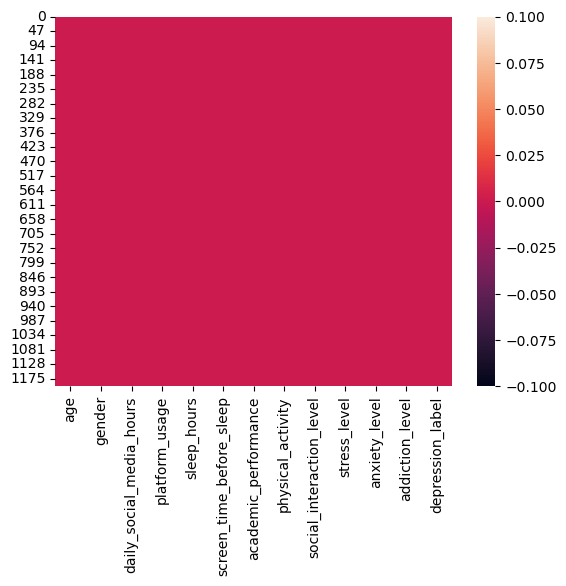

In [21]:
sns.heatmap(df.isnull())
plt.show()

In [157]:
df['screen_exposure'] = df['sleep_hours'] + df['screen_time_before_sleep']

## Performing EDA

### Depression Rate of Gender vs Platform

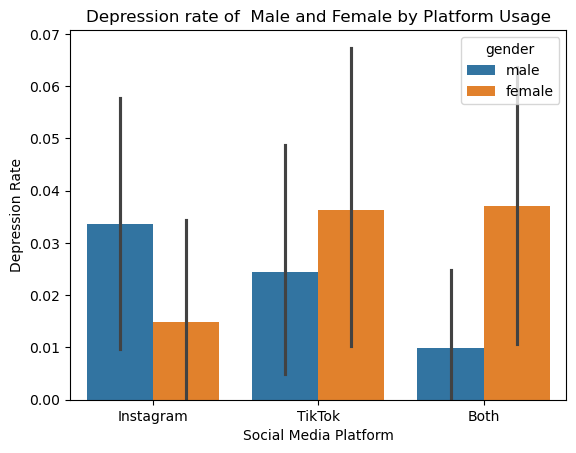

In [137]:
sns.barplot(x='platform_usage', y='depression_label' ,hue = 'gender', data=df)
plt.title('Depression rate of  Male and Female by Platform Usage')
plt.xlabel('Social Media Platform')
plt.ylabel('Depression Rate')
plt.show()

### Social Media Usage Vs Depression Label

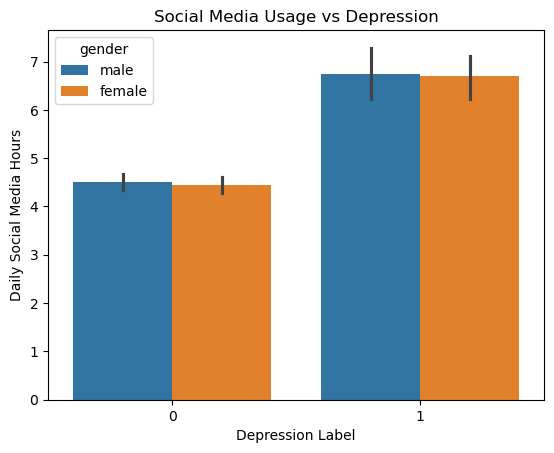

In [151]:
sns.barplot(x='depression_label', y='daily_social_media_hours',hue='gender', data=df)
plt.title('Social Media Usage vs Depression')
plt.xlabel('Depression Label')
plt.ylabel('Daily Social Media Hours')
plt.show()

### Depression Label vs Screen Exposure

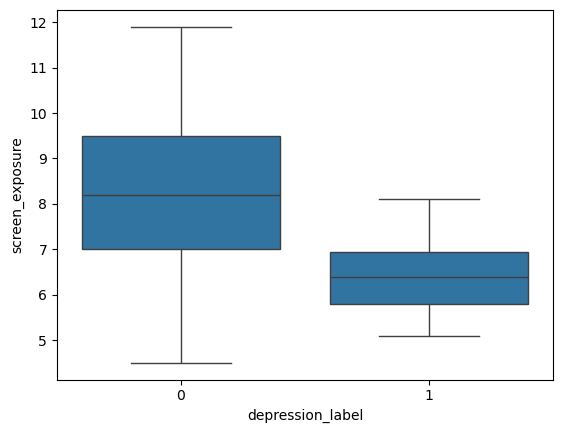

In [163]:
sns.boxplot(x='depression_label',y='screen_exposure',data=df)
plt.show()

In [17]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label',
       'screen_exposure'],
      dtype='object')

### Physical Activity vs Stress Level

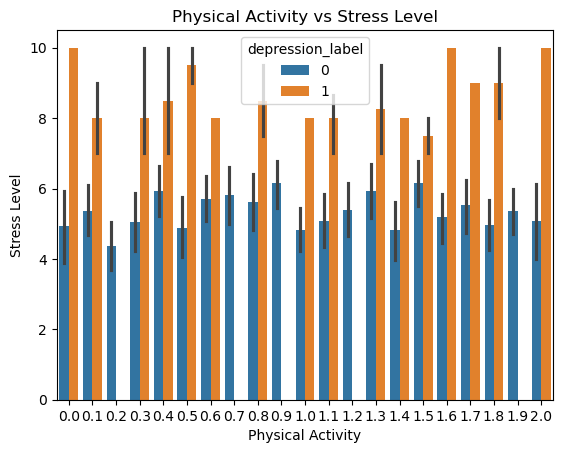

In [19]:
sns.barplot(x='physical_activity',y='stress_level',hue='depression_label',data=df)
plt.xlabel('Physical Activity')
plt.ylabel('Stress Level')
plt.title('Physical Activity vs Stress Level')
plt.show()

### Social Interaction vs Depression

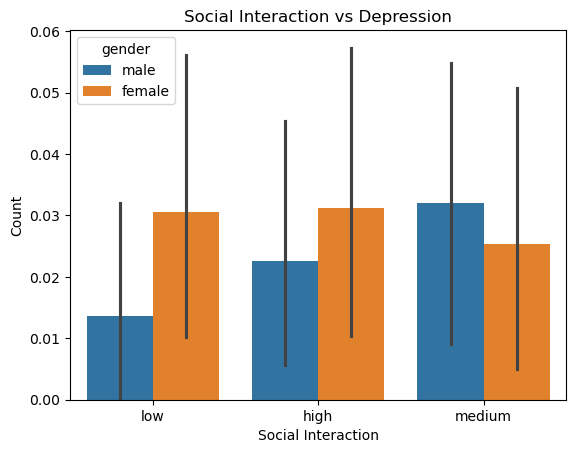

In [145]:
sns.barplot(x='social_interaction_level', y='depression_label',hue='gender', data=df)
plt.title('Social Interaction vs Depression')
plt.xlabel('Social Interaction')
plt.ylabel('Count')
plt.show()

### Corelation Map

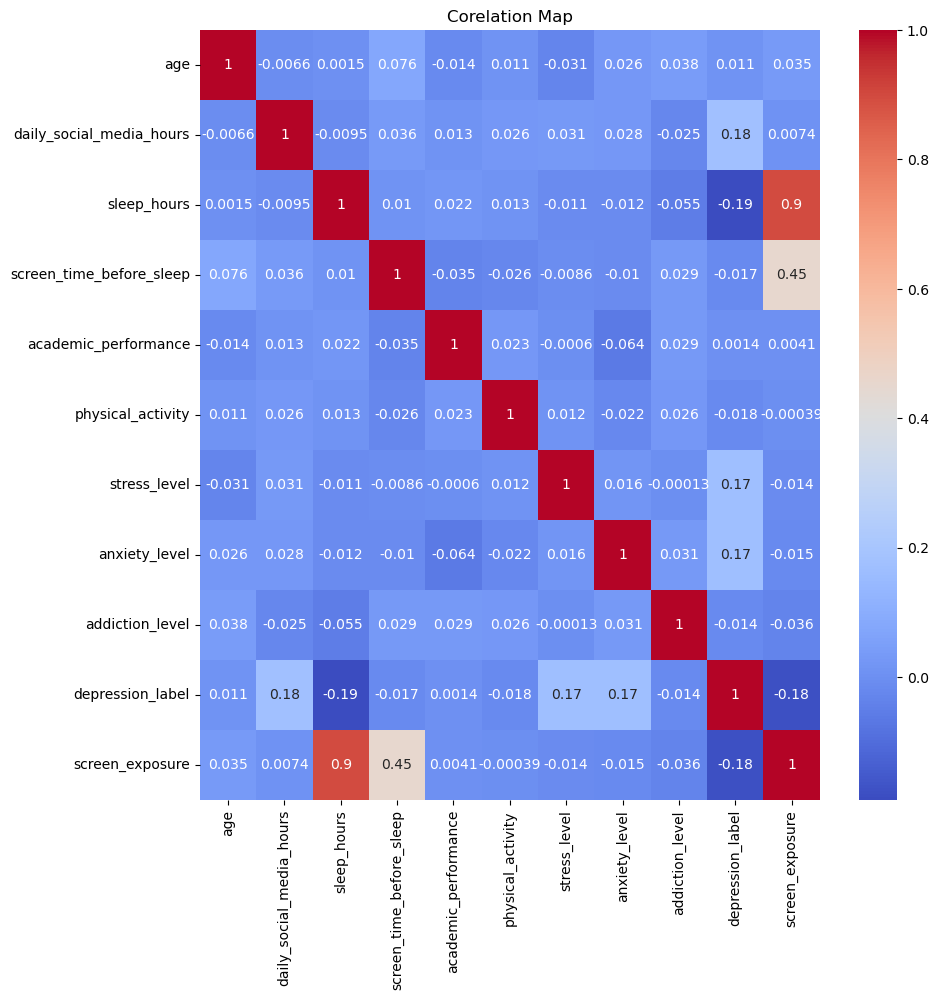

In [103]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True) , annot = True , cmap='coolwarm')
plt.title('Corelation Map')
plt.show()

In [121]:
df['gender'].unique()
df['platform_usage'].unique()
#df['social_interaction_level'].unique

array(['Instagram', 'TikTok', 'Both'], dtype=object)

## Feature Engineering

In [51]:
df['gender'] = df['gender'].map({'female':0 , 'male':1})


In [53]:
df['platform_usage'] = df['platform_usage'].map({'Instagram':0 , 'TikTok':1 , 'Both':2})

In [177]:
df['social_interaction_level'] = df['social_interaction_level'].map({'low':0 , 'high':2 , 'medium':2})

## Model Training Using ML Algorithms

In [63]:
x = df.drop(columns='depression_label',axis=1)
y = df['depression_label']

In [65]:
from sklearn.model_selection import train_test_split


In [67]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Using Algorithms For Training
### 1. Logistic Regression
### 2. RandomForestClassifier
### 3. XGBClassifier
### 4. DecisionTreeClassifier

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , accuracy_score

## Logistic Regression

In [73]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [77]:
y_pred_lr = lr.predict(x_test)
accu_lr = accuracy_score(y_test , y_pred_lr)

In [87]:
print('Logistic Regression Accuracy :' , accu_lr)

Logistic Regression Accuracy : 0.9916666666666667


In [81]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240



## RandomForestClassifier

In [95]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [97]:
y_pred_rfc = rfc.predict(x_test)
accu_rfc = accuracy_score(y_test , y_pred_rfc)

In [101]:
print('RandomForestClassifier Accuracy :', accu_rfc)

RandomForestClassifier Accuracy : 0.9791666666666666


In [103]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



## XGBClassifier

In [105]:
xg = XGBClassifier()
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [107]:
y_pred_xg = xg.predict(x_test)
accu_xg = accuracy_score(y_test , y_pred_xg)

In [109]:
print('XGBClassifier Accuracy :',accu_xg)

XGBClassifier Accuracy : 0.9958333333333333


In [111]:
print(classification_report(y_test , y_pred_xg))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      0.83      0.91         6

    accuracy                           1.00       240
   macro avg       1.00      0.92      0.95       240
weighted avg       1.00      1.00      1.00       240



## DecisionTreeClassifier

In [113]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [115]:
y_pred_dt = dt.predict(x_test)
accu_dt = accuracy_score(y_test , y_pred_dt)

In [117]:
print("Decision Tree Classifier Accuracy :", accu_dt)

Decision Tree Classifier Accuracy : 0.9916666666666667


In [119]:
print(classification_report(y_test , y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.83      0.83      0.83         6

    accuracy                           0.99       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.99      0.99      0.99       240



## Summary

### Logistic Regression Accuracy : 0.9916
### RandomForestClassifier Accuracy : 0.9791
### XGBClassifier Accuracy : 0.9958
### Decision Tree Classifier Accuracy : 0.9916

In [ ]:
## 